### Quantitative and Qualitative Evaluation on Static Background Videos
This notebook reproduces the experimental results for the static background grayscale video sequence presented in Section 5.3.1 of the paper. It loads the pre-computed tensor states, reconstructs the videos, and computes the seven mathematical and perceptual metrics (RE, M-RMSE, PSNR, SSIM, MS-SSIM, LPIPS, VMAF) shown in Table 4, 5.

In [ ]:
# ---------------------------------------------------------
# Environment Setup and Deep Learning Metric Initialization
# ---------------------------------------------------------
using LinearAlgebra
using Plots
using ImageQualityIndexes
using Images
using ImageIO
using FileIO
using FFMPEG_jll
using Printf
using Statistics
using Revise
using JLD2
using PyCall

In [ ]:
# Include custom modules containing the proposed Online TT-ALS, baseline algorithms, and metric functions
includet("../julia_source/myGenerateData.jl")
includet("../julia_source/myLoadVideo.jl")
includet("../julia_source/myTTD.jl")
includet("../julia_source/myIndicator.jl")

In [3]:
r = 10;

@load "data_color_continuousPan_$(r).jld2" video_tensor_est video_tensor_FOA_est video_tensor_batch_est_full video_tensor_batchSlice_est

save_color_video(video_tensor_est, "Online TT-ALS", [r, 3, 3], "results/color/continuousPan", "continuousPan_onlineALS_est_$(r).mp4")
save_color_video(video_tensor_FOA_est, "TT-FOA", [r, 3, 3], "results/color/continuousPan", "continuousPan_FOA_est_$(r).mp4")
save_color_video(video_tensor_batch_est_full, "TT-ALS", [r, 3, 3], "results/color/continuousPan", "continuousPan_batchALS_est_full_$(r).mp4")
save_color_video(video_tensor_batchSlice_est, "TT-ALS (Slice)", [r, 3], "results/color/continuousPan", "continuousPan_batchSliceALS_est_$(r).mp4")

[ Info: Saved animation to /home/takeda/12/results/color/continuousPan/continuousPan_onlineALS_est_10.mp4


動画を保存しました: results/color/continuousPan/continuousPan_onlineALS_est_10.mp4
動画を保存しました: results/color/continuousPan/continuousPan_FOA_est_10.mp4


[ Info: Saved animation to /home/takeda/12/results/color/continuousPan/continuousPan_FOA_est_10.mp4


動画を保存しました: results/color/continuousPan/continuousPan_batchALS_est_full_10.mp4


[ Info: Saved animation to /home/takeda/12/results/color/continuousPan/continuousPan_batchALS_est_full_10.mp4


動画を保存しました: results/color/continuousPan/continuousPan_batchSliceALS_est_10.mp4


[ Info: Saved animation to /home/takeda/12/results/color/continuousPan/continuousPan_batchSliceALS_est_10.mp4


In [4]:
r = 30;

@load "data_color_continuousPan_$(r).jld2" video_tensor_est video_tensor_FOA_est video_tensor_batch_est_full video_tensor_batchSlice_est

save_color_video(video_tensor_est, "Online TT-ALS", [r, 3, 3], "results/color/continuousPan", "continuousPan_onlineALS_est_$(r).mp4")
save_color_video(video_tensor_FOA_est, "TT-FOA", [r, 3, 3], "results/color/continuousPan", "continuousPan_FOA_est_$(r).mp4")
save_color_video(video_tensor_batch_est_full, "TT-ALS", [r, 3, 3], "results/color/continuousPan", "continuousPan_batchALS_est_full_$(r).mp4")
save_color_video(video_tensor_batchSlice_est, "TT-ALS (Slice)", [r, 3], "results/color/continuousPan", "continuousPan_batchSliceALS_est_$(r).mp4")

動画を保存しました: results/color/continuousPan/continuousPan_onlineALS_est_30.mp4


[ Info: Saved animation to /home/takeda/12/results/color/continuousPan/continuousPan_onlineALS_est_30.mp4


動画を保存しました: results/color/continuousPan/continuousPan_FOA_est_30.mp4


[ Info: Saved animation to /home/takeda/12/results/color/continuousPan/continuousPan_FOA_est_30.mp4


動画を保存しました: results/color/continuousPan/continuousPan_batchALS_est_full_30.mp4


[ Info: Saved animation to /home/takeda/12/results/color/continuousPan/continuousPan_batchALS_est_full_30.mp4


動画を保存しました: results/color/continuousPan/continuousPan_batchSliceALS_est_30.mp4


[ Info: Saved animation to /home/takeda/12/results/color/continuousPan/continuousPan_batchSliceALS_est_30.mp4


In [5]:
# video_tensor, h, w, T = load_color_video("../colorVideo/pedestrians/input")
video_tensor, h, w, T = load_color_video("../.cache/kagglehub/datasets/maamri95/cdnet2014/versions/1/dataset/PTZ/continuousPan/input")
T = 500;
# video_tensor = video_tensor[:, :, :, 251:250+T];
video_tensor = video_tensor[:, :, :, 1:T];
# save_color_video(video_tensor, "Original", [0], "results/color/continuousPan", "continuousPan_original.mp4")

In [ ]:
# Initialize the LPIPS perceptual loss model (AlexNet backbone is standard and highly efficient)
# This neural network-based metric is crucial for evaluating the perceptual fidelity of the reconstructed videos
const lpips = pyimport("lpips");
const torch = pyimport("torch");
const loss_fn = lpips.LPIPS(net="alex");

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/takeda/.local/lib/python3.9/site-packages/lpips/weights/v0.1/alex.pth


/home/takeda/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/takeda/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
@load "data_color_continuousPan_10.jld2" video_tensor_est video_tensor_FOA_est video_tensor_batch_est_full video_tensor_batchSlice_est iter_time iter_time_FOA iter_time_batch iter_time_batchSlice

8-element Vector{Symbol}:
 :video_tensor_est
 :video_tensor_FOA_est
 :video_tensor_batch_est_full
 :video_tensor_batchSlice_est
 :iter_time
 :iter_time_FOA
 :iter_time_batch
 :iter_time_batchSlice

### Dataset Preparation & Loading (Color Video)

Due to file size limits and licensing, the original video datasets are not included in this repository. 
To reproduce our experiments, please download the "continuousPan" sequence from the [CDnet 2014 benchmark](http://www.changedetection.net/).

**Note for custom video sequences:**
If you wish to evaluate the algorithms on your own custom color video data, prepare a folder containing the sequential frame images and update the folder path in the `load_color_video("path/to/your/custom/video")` function below.

In [8]:
# video_tensor, h, w, T = load_color_video("../colorVideo/pedestrians/input")
# T = 500;
# video_tensor = video_tensor[:, :, :, 251:250+T];
video_tensor, h, w, T = load_color_video("../.cache/kagglehub/datasets/maamri95/cdnet2014/versions/1/dataset/PTZ/continuousPan/input")
T = 500;
video_tensor = video_tensor[:, :, :, 1:T];

ttsizes = [h, w, T];
ttranks = [10, 3, 3];

@show ttsizes;

ttsizes = [480, 704, 500]


In [9]:
save_color_frame(video_tensor, "fig/color/pedestrians", "pedestrians_original_frame220.pdf", 220)
save_color_frame(video_tensor_est, "fig/color/pedestrians", "pedestrians_onlineALS_est_10_frame220.pdf", 220)
save_color_frame(video_tensor_FOA_est, "fig/color/pedestrians", "pedestrians_FOA_est_10_frame220.pdf", 220)
save_color_frame(video_tensor_batch_est_full, "fig/color/pedestrians", "pedestrians_batchALS_est_full_10_frame220.pdf", 220)
save_color_frame(video_tensor_batchSlice_est, "fig/color/pedestrians", "pedestrians_batchSliceALS_est_10_frame220.pdf", 220)

"/home/takeda/12/fig/color/pedestrians/pedestrians_batchSliceALS_est_10_frame220.pdf"

In [10]:
@show size(video_tensor_est);

size(video_tensor_est) = (240, 360, 3, 500)


In [9]:
true_norm = norm(video_tensor)

nonmasked_rmse_true = norm(video_tensor - video_tensor) / true_norm
nonmasked_rmse_batch = norm(video_tensor_batch_est_full - video_tensor) / true_norm
nonmasked_rmse_batchSlice = norm(video_tensor_batchSlice_est - video_tensor) / true_norm
nonmasked_rmse_foa = norm(video_tensor_FOA_est - video_tensor) / true_norm
nonmasked_rmse_ours = norm(video_tensor_est - video_tensor) / true_norm

@printf("Non-masked RMSE True: %.6f\n", nonmasked_rmse_true);
@printf("Non-masked RMSE Batch: %.6f\n", nonmasked_rmse_batch);
@printf("Non-masked RMSE Batch Slice: %.6f\n", nonmasked_rmse_batchSlice);
@printf("Non-masked RMSE FOA: %.6f\n", nonmasked_rmse_foa);
@printf("Non-masked RMSE Ours: %.6f\n", nonmasked_rmse_ours);

Non-masked RMSE True: 0.000000
Non-masked RMSE Batch: 0.221263
Non-masked RMSE Batch Slice: 0.165903
Non-masked RMSE FOA: 0.202834
Non-masked RMSE Ours: 0.121548


In [10]:
masked_rmse_true = calc_masked_rmse_color(video_tensor, video_tensor; threshold=0.1)
masked_rmse_batch = calc_masked_rmse_color(video_tensor, video_tensor_batch_est_full; threshold=0.1)
masked_rmse_batchSlice = calc_masked_rmse_color(video_tensor, video_tensor_batchSlice_est; threshold=0.1)
masked_rmse_foa = calc_masked_rmse_color(video_tensor, video_tensor_FOA_est; threshold=0.1)
masked_rmse_ours = calc_masked_rmse_color(video_tensor, video_tensor_est; threshold=0.1)
@printf("Masked RMSE True: %.6f\n", masked_rmse_true);
@printf("Masked RMSE Batch: %.6f\n", masked_rmse_batch);
@printf("Masked RMSE Batch Slice: %.6f\n", masked_rmse_batchSlice);
@printf("Masked RMSE FOA: %.6f\n", masked_rmse_foa);
@printf("Masked RMSE Ours: %.6f\n", masked_rmse_ours);

Masked RMSE True: 0.000000
Masked RMSE Batch: 0.214257
Masked RMSE Batch Slice: 0.146151
Masked RMSE FOA: 0.137503
Masked RMSE Ours: 0.111021


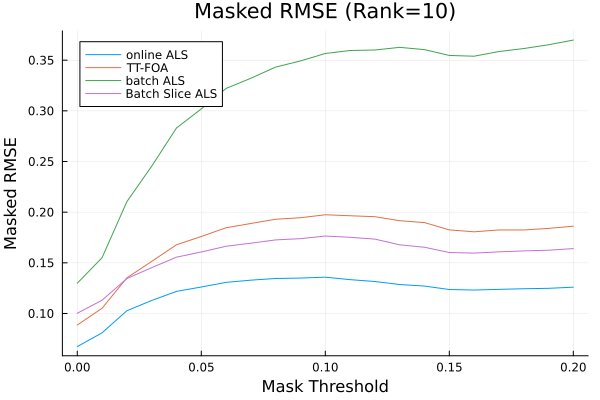

In [ ]:
# thresholds = 0.0:0.01:0.2
# rmse_onlineALS = []
# rmse_onlineFOA = []
# rmse_batchALS = []
# rmse_batchSliceALS = []

# for th in thresholds
#     push!(rmse_onlineALS, calc_masked_rmse_color(video_tensor, video_tensor_est; threshold=th))
#     push!(rmse_onlineFOA,  calc_masked_rmse_color(video_tensor, video_tensor_FOA_est; threshold=th))
#     push!(rmse_batchALS,  calc_masked_rmse_color(video_tensor, video_tensor_batch_est_full; threshold=th))
#     push!(rmse_batchSliceALS,  calc_masked_rmse_color(video_tensor, video_tensor_batchSlice_est; threshold=th))
# end

# p = plot(thresholds, [rmse_onlineALS, rmse_onlineFOA, rmse_batchALS, rmse_batchSliceALS], label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], 
#      xlabel="Mask Threshold", ylabel="Masked RMSE", title="Masked RMSE (Rank=10)")
# savefig(p, "fig/color/pedestrians/masked_rmse_10.pdf")
# display(p)

In [11]:
avg_ssim_true, ssim_list_true = calc_video_ssim_color(video_tensor, video_tensor);
avg_ssim_batch, ssim_list_batch = calc_video_ssim_color(video_tensor, video_tensor_batch_est_full);
avg_ssim_batchSlice, ssim_list_batchSlice = calc_video_ssim_color(video_tensor, video_tensor_batchSlice_est);
avg_ssim_foa, ssim_list_foa = calc_video_ssim_color(video_tensor, video_tensor_FOA_est);
avg_ssim_ours, ssim_list_ours = calc_video_ssim_color(video_tensor, video_tensor_est);

@printf("Average SSIM True: %.6f\n", avg_ssim_true);
@printf("Average SSIM Batch: %.6f\n", avg_ssim_batch);
@printf("Average SSIM Batch Slice: %.6f\n", avg_ssim_batchSlice);
@printf("Average SSIM FOA: %.6f\n", avg_ssim_foa);
@printf("Average SSIM Ours: %.6f\n", avg_ssim_ours);

# p = plot([ssim_list_ours, ssim_list_foa, ssim_list_batch, ssim_list_batchSlice], 
#      label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="SSIM", title="SSIM per Frame (Rank=10)")
# savefig(p, "fig/color/pedestrians/ssim_per_frame_10.pdf")
# display(p)

Average SSIM True: 1.000000
Average SSIM Batch: 0.462801
Average SSIM Batch Slice: 0.507171
Average SSIM FOA: 0.636395
Average SSIM Ours: 0.646019


In [12]:
avg_msssim_true, msssim_list_true = calc_video_msssim_color(video_tensor, video_tensor);
avg_msssim_batch, msssim_list_batch = calc_video_msssim_color(video_tensor, video_tensor_batch_est_full);
avg_msssim_batchSlice, msssim_list_batchSlice = calc_video_msssim_color(video_tensor, video_tensor_batchSlice_est);
avg_msssim_foa, msssim_list_foa = calc_video_msssim_color(video_tensor, video_tensor_FOA_est);
avg_msssim_ours, msssim_list_ours = calc_video_msssim_color(video_tensor, video_tensor_est);

@printf("Average MS-SSIM True: %.6f\n", avg_msssim_true);
@printf("Average MS-SSIM Batch: %.6f\n", avg_msssim_batch);
@printf("Average MS-SSIM Batch Slice: %.6f\n", avg_msssim_batchSlice);
@printf("Average MS-SSIM FOA: %.6f\n", avg_msssim_foa);
@printf("Average MS-SSIM Ours: %.6f\n", avg_msssim_ours);

# p = plot([msssim_list_ours, msssim_list_foa, msssim_list_batch, msssim_list_batchSlice], 
#      label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="MS-SSIM", title="MS-SSIM per Frame (Rank=10)")
# savefig(p, "fig/color/pedestrians/ms-ssim_per_frame_10.pdf")
# display(p)

Average MS-SSIM True: 1.000029
Average MS-SSIM Batch: 0.397248
Average MS-SSIM Batch Slice: 0.578711
Average MS-SSIM FOA: 0.716637
Average MS-SSIM Ours: 0.740399


In [13]:
avg_psnr_true, psnr_list_true = calc_video_psnr_color(video_tensor, video_tensor);
avg_psnr_batch, psnr_list_batch = calc_video_psnr_color(video_tensor, video_tensor_batch_est_full);
avg_psnr_batchSlice, psnr_list_batchSlice = calc_video_psnr_color(video_tensor, video_tensor_batchSlice_est);
avg_psnr_foa, psnr_list_foa = calc_video_psnr_color(video_tensor, video_tensor_FOA_est);
avg_psnr_ours, psnr_list_ours = calc_video_psnr_color(video_tensor, video_tensor_est);

@printf("Average PSNR True: %.6f\n", avg_psnr_true);
@printf("Average PSNR Batch: %.6f\n", avg_psnr_batch);
@printf("Average PSNR Batch Slice: %.6f\n", avg_psnr_batchSlice);
@printf("Average PSNR FOA: %.6f\n", avg_psnr_foa);
@printf("Average PSNR Ours: %.6f\n", avg_psnr_ours);

# p = plot([psnr_list_ours, psnr_list_foa, psnr_list_batch, psnr_list_batchSlice], 
#      label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="PSNR (dB)", title="PSNR per Frame (Rank=10)")
# savefig(p, "fig/color/pedestrians/psnr_per_frame_10.pdf")
# display(p)

Average PSNR True: Inf
Average PSNR Batch: 17.463425
Average PSNR Batch Slice: 20.106884
Average PSNR FOA: 21.522732
Average PSNR Ours: 22.804835


In [14]:
avg_lpips_true, lpips_list_true = calc_video_lpips_color(video_tensor, video_tensor);
avg_lpips_batch, lpips_list_batch = calc_video_lpips_color(video_tensor, video_tensor_batch_est_full);
avg_lpips_batchSlice, lpips_list_batchSlice = calc_video_lpips_color(video_tensor, video_tensor_batchSlice_est);
avg_lpips_foa, lpips_list_foa = calc_video_lpips_color(video_tensor, video_tensor_FOA_est);
avg_lpips_ours, lpips_list_ours = calc_video_lpips_color(video_tensor, video_tensor_est);

@printf("Average LPIPS True: %.6f\n", avg_lpips_true);
@printf("Average LPIPS Batch: %.6f\n", avg_lpips_batch);
@printf("Average LPIPS Batch Slice: %.6f\n", avg_lpips_batchSlice);
@printf("Average LPIPS FOA: %.6f\n", avg_lpips_foa);
@printf("Average LPIPS Ours: %.6f\n", avg_lpips_ours);

# p = plot([lpips_list_ours, lpips_list_foa, lpips_list_batch, lpips_list_batchSlice], 
#      label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="LPIPS", title="LPIPS per Frame (Rank=10)")
# savefig(p, "fig/color/pedestrians/lpips_per_frame_10.pdf")
# display(p)

Average LPIPS True: 0.000000
Average LPIPS Batch: 0.668021
Average LPIPS Batch Slice: 0.543806
Average LPIPS FOA: 0.568691
Average LPIPS Ours: 0.520912


In [15]:
vmaf_true = calc_video_vmaf_color(video_tensor, video_tensor);
vmaf_batch = calc_video_vmaf_color(video_tensor, video_tensor_batch_est_full);
vmaf_batchSlice = calc_video_vmaf_color(video_tensor, video_tensor_batchSlice_est);
vmaf_foa = calc_video_vmaf_color(video_tensor, video_tensor_FOA_est);
vmaf_ours = calc_video_vmaf_color(video_tensor, video_tensor_est);

@printf("VMAF True: %.6f\n", vmaf_true);
@printf("VMAF Batch: %.6f\n", vmaf_batch);
@printf("VMAF Batch Slice: %.6f\n", vmaf_batchSlice);
@printf("VMAF FOA: %.6f\n", vmaf_foa);
@printf("VMAF Ours: %.6f\n", vmaf_ours);

VMAF True: 99.929655
VMAF Batch: 7.221294
VMAF Batch Slice: 28.860077
VMAF FOA: 37.961421
VMAF Ours: 45.060607


In [ ]:
"""
Helper function to format evaluation metrics for LaTeX tables.
It automatically highlights the best value in bold and the second-best value with an underline.
"""
function fmt_rank(val, all_vals; high_is_better=true, fmt="%.3f")
    sorted = sort(all_vals, rev=high_is_better)
    val_str = Printf.format(Printf.Format(fmt), val)
    
    if val == sorted[1]
        return "\\textbf{$val_str}"
    elseif val == sorted[2]
        return "\\underline{$val_str}"
    else
        return val_str
    end
end

# ---------------------------------------------------------
# Data Aggregation
# ---------------------------------------------------------
# Aggregate the calculated metrics into arrays corresponding to each algorithm.
# The expected order is: [TT-ALS, TT-ALS (Slice), TT-FOA, Online TT-ALS (Ours)]

re_all      = [nonmasked_rmse_batch, nonmasked_rmse_batchSlice, nonmasked_rmse_foa, nonmasked_rmse_ours]
m_rmse_all  = [masked_rmse_batch, masked_rmse_batchSlice, masked_rmse_foa, masked_rmse_ours]
psnr_all    = [avg_psnr_batch, avg_psnr_batchSlice, avg_psnr_foa, avg_psnr_ours]
ssim_all    = [avg_ssim_batch, avg_ssim_batchSlice, avg_ssim_foa, avg_ssim_ours]
ms_ssim_all = [avg_msssim_batch, avg_msssim_batchSlice, avg_msssim_foa, avg_msssim_ours]
lpips_all   = [avg_lpips_batch, avg_lpips_batchSlice, avg_lpips_foa, avg_lpips_ours]
vmaf_all    = [vmaf_batch, vmaf_batchSlice, vmaf_foa, vmaf_ours]
mean_time_all = [mean(iter_time_batch), mean(iter_time_batchSlice), mean(iter_time_FOA), mean(iter_time)]

method_names = [
    "TT-ALS              ",
    "TT-ALS (Slice)      ",
    "TT-FOA              ",
    "Online TT-ALS (Ours)"
]

# ---------------------------------------------------------
# LaTeX Table Generation
# ---------------------------------------------------------
# Automatically generate the LaTeX code for the quantitative evaluation table.
# This output can be directly copied and pasted into the paper's .tex file.

println(raw"\begin{table}[t]")
println(raw"\centering")
println(raw"\caption{Quantitative comparison of algorithms on the color video ($r=(10,3,3)$).}")
println(raw"\label{tab:comparison_color_10}")
println(raw"\resizebox{\columnwidth}{!}{")
println(raw"\begin{tabular}{l cc c cc c cc c}")
println(raw"\toprule")
println(raw"& \multicolumn{3}{c}{\textbf{Mathematical}} & \multicolumn{2}{c}{\textbf{Structural}} & \multicolumn{2}{c}{\textbf{Perceptual}} & \textbf{Time} \\")
println(raw"\cmidrule(lr){2-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-9}")
println(raw"\textbf{Method} & RE $\downarrow$ & M-RMSE $\downarrow$ & PSNR $\uparrow$ & SSIM $\uparrow$ & MS-SSIM $\uparrow$ & LPIPS $\downarrow$ & VMAF $\uparrow$ & \makecell{Mean Time \\ (ms) $\downarrow$} \\") 
println(raw"\midrule")

# Iterate through the algorithms and format each row
for i in 1:length(method_names)
    @printf("%s & %s & %s & %s & %s & %s & %s & %s & %s \\\\\n",
        method_names[i],
        # RE (Lower is better: high_is_better=false)
        fmt_rank(re_all[i], re_all, high_is_better=false, fmt="%.3f"),
        # M-RMSE (Lower is better: high_is_better=false)
        fmt_rank(m_rmse_all[i], m_rmse_all, high_is_better=false, fmt="%.3f"),
        # PSNR (Higher is better: high_is_better=true)
        fmt_rank(psnr_all[i], psnr_all, high_is_better=true, fmt="%.2f"),
        # SSIM (Higher is better: high_is_better=true)
        fmt_rank(ssim_all[i], ssim_all, high_is_better=true, fmt="%.3f"),
        # MS-SSIM (Higher is better: high_is_better=true)
        fmt_rank(ms_ssim_all[i], ms_ssim_all, high_is_better=true, fmt="%.3f"),
        # LPIPS (Lower is better: high_is_better=false)
        fmt_rank(lpips_all[i], lpips_all, high_is_better=false, fmt="%.3f"),
        # VMAF (Higher is better: high_is_better=true)
        fmt_rank(vmaf_all[i], vmaf_all, high_is_better=true, fmt="%.2f"),
        # Mean Time (Lower is better: high_is_better=false)
        fmt_rank(mean_time_all[i], mean_time_all, high_is_better=false, fmt="%.3f")
    )
end

println(raw"\bottomrule")
println(raw"\end{tabular}")
println(raw"}")
println(raw"\end{table}")

\begin{table}[t]
\centering
\caption{カラー動画における各アルゴリズムの定量評価結果の比較（$r=(10,3,3)$）．}
\label{tab:comparison_color_10}
\resizebox{\columnwidth}{!}{
\begin{tabular}{l cc c cc c cc c}
\toprule
& \multicolumn{3}{c}{\textbf{数理的指標}} & \multicolumn{2}{c}{\textbf{構造的指標}} & \multicolumn{2}{c}{\textbf{知覚・動画品質指標}} & \textbf{実行時間} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-9}
\textbf{手法} & RE $\downarrow$ & M-RMSE $\downarrow$ & PSNR $\uparrow$ & SSIM $\uparrow$ & MS-SSIM $\uparrow$ & LPIPS $\downarrow$ & VMAF $\uparrow$ & \makecell{Mean Time \\ (ms) $\downarrow$} \\
\midrule
TT-ALS                & 0.221 & 0.214 & 17.46 & 0.463 & 0.397 & 0.668 & 7.22 & 23529.517 \\
TT-ALS (Slice)        & \underline{0.166} & 0.146 & 20.11 & 0.507 & 0.579 & \underline{0.544} & 28.86 & \underline{50.733} \\
TT-FOA                & 0.203 & \underline{0.138} & \underline{21.52} & \underline{0.636} & \underline{0.717} & 0.569 & \underline{37.96} & 52.129 \\
Online TT-ALS（提案手法） & \textbf{0.12

# Color (rank=(30, 30, 3))

In [17]:
@load "data_color_continuousPan_30.jld2" video_tensor_est video_tensor_FOA_est video_tensor_batch_est_full video_tensor_batchSlice_est iter_time iter_time_FOA iter_time_batch iter_time_batchSlice

8-element Vector{Symbol}:
 :video_tensor_est
 :video_tensor_FOA_est
 :video_tensor_batch_est_full
 :video_tensor_batchSlice_est
 :iter_time
 :iter_time_FOA
 :iter_time_batch
 :iter_time_batchSlice

In [19]:
save_color_frame(video_tensor, "fig/color/pedestrians", "pedestrians_original_frame220.pdf", 220)
save_color_frame(video_tensor_est, "fig/color/pedestrians", "pedestrians_onlineALS_est_30_frame220.pdf", 220)
save_color_frame(video_tensor_FOA_est, "fig/color/pedestrians", "pedestrians_FOA_est_30_frame220.pdf", 220)
save_color_frame(video_tensor_batch_est_full, "fig/color/pedestrians", "pedestrians_batchALS_est_full_30_frame220.pdf", 220)
save_color_frame(video_tensor_batchSlice_est, "fig/color/pedestrians", "pedestrians_batchSliceALS_est_30_frame220.pdf", 220)

"/home/takeda/12/fig/color/pedestrians/pedestrians_batchSliceALS_est_30_frame220.pdf"

In [18]:
true_norm = norm(video_tensor)

nonmasked_rmse_true = norm(video_tensor - video_tensor) / true_norm
nonmasked_rmse_batch = norm(video_tensor_batch_est_full - video_tensor) / true_norm
nonmasked_rmse_batchSlice = norm(video_tensor_batchSlice_est - video_tensor) / true_norm
nonmasked_rmse_foa = norm(video_tensor_FOA_est - video_tensor) / true_norm
nonmasked_rmse_ours = norm(video_tensor_est - video_tensor) / true_norm

@printf("Non-masked RMSE True: %.6f\n", nonmasked_rmse_true);
@printf("Non-masked RMSE Batch: %.6f\n", nonmasked_rmse_batch);
@printf("Non-masked RMSE Batch Slice: %.6f\n", nonmasked_rmse_batchSlice);
@printf("Non-masked RMSE FOA: %.6f\n", nonmasked_rmse_foa);
@printf("Non-masked RMSE Ours: %.6f\n", nonmasked_rmse_ours);

Non-masked RMSE True: 0.000000
Non-masked RMSE Batch: 0.203410
Non-masked RMSE Batch Slice: 0.112103
Non-masked RMSE FOA: 0.192831
Non-masked RMSE Ours: 0.085276


In [19]:
masked_rmse_true = calc_masked_rmse_color(video_tensor, video_tensor; threshold=0.1)
masked_rmse_batch = calc_masked_rmse_color(video_tensor, video_tensor_batch_est_full; threshold=0.1)
masked_rmse_batchSlice = calc_masked_rmse_color(video_tensor, video_tensor_batchSlice_est; threshold=0.1)
masked_rmse_foa = calc_masked_rmse_color(video_tensor, video_tensor_FOA_est; threshold=0.1)
masked_rmse_ours = calc_masked_rmse_color(video_tensor, video_tensor_est; threshold=0.1)
@printf("Masked RMSE True: %.6f\n", masked_rmse_true);
@printf("Masked RMSE Batch: %.6f\n", masked_rmse_batch);
@printf("Masked RMSE Batch Slice: %.6f\n", masked_rmse_batchSlice);
@printf("Masked RMSE FOA: %.6f\n", masked_rmse_foa);
@printf("Masked RMSE Ours: %.6f\n", masked_rmse_ours);

Masked RMSE True: 0.000000
Masked RMSE Batch: 0.198732
Masked RMSE Batch Slice: 0.092785
Masked RMSE FOA: 0.111907
Masked RMSE Ours: 0.072671


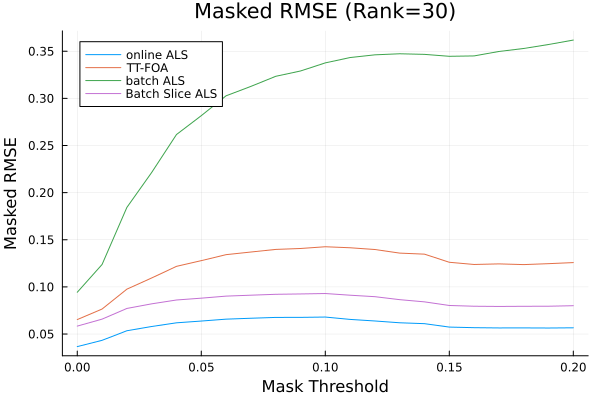

In [ ]:
# thresholds = 0.0:0.01:0.2
# rmse_onlineALS = []
# rmse_onlineFOA = []
# rmse_batchALS = []
# rmse_batchSliceALS = []

# for th in thresholds
#     push!(rmse_onlineALS, calc_masked_rmse_color(video_tensor, video_tensor_est; threshold=th))
#     push!(rmse_onlineFOA,  calc_masked_rmse_color(video_tensor, video_tensor_FOA_est; threshold=th))
#     push!(rmse_batchALS,  calc_masked_rmse_color(video_tensor, video_tensor_batch_est_full; threshold=th))
#     push!(rmse_batchSliceALS,  calc_masked_rmse_color(video_tensor, video_tensor_batchSlice_est; threshold=th))
# end

# p = plot(thresholds, [rmse_onlineALS, rmse_onlineFOA, rmse_batchALS, rmse_batchSliceALS], label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], 
#      xlabel="Mask Threshold", ylabel="Masked RMSE", title="Masked RMSE (Rank=30)")
# savefig(p, "fig/color/pedestrians/masked_rmse_30.pdf")
# display(p)

In [20]:
avg_ssim_true, ssim_list_true = calc_video_ssim_color(video_tensor, video_tensor);
avg_ssim_batch, ssim_list_batch = calc_video_ssim_color(video_tensor, video_tensor_batch_est_full);
avg_ssim_batchSlice, ssim_list_batchSlice = calc_video_ssim_color(video_tensor, video_tensor_batchSlice_est);
avg_ssim_foa, ssim_list_foa = calc_video_ssim_color(video_tensor, video_tensor_FOA_est);
avg_ssim_ours, ssim_list_ours = calc_video_ssim_color(video_tensor, video_tensor_est);

@printf("Average SSIM True: %.6f\n", avg_ssim_true);
@printf("Average SSIM Batch: %.6f\n", avg_ssim_batch);
@printf("Average SSIM Batch Slice: %.6f\n", avg_ssim_batchSlice);
@printf("Average SSIM FOA: %.6f\n", avg_ssim_foa);
@printf("Average SSIM Ours: %.6f\n", avg_ssim_ours);

# p = plot([ssim_list_ours, ssim_list_foa, ssim_list_batch, ssim_list_batchSlice], 
#      label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="SSIM", title="SSIM per Frame (Rank=30)")
# savefig(p, "fig/color/pedestrians/ssim_per_frame_30.pdf")
# display(p)

Average SSIM True: 1.000000
Average SSIM Batch: 0.525845
Average SSIM Batch Slice: 0.601156
Average SSIM FOA: 0.702414
Average SSIM Ours: 0.720673


In [21]:
avg_msssim_true, msssim_list_true = calc_video_msssim_color(video_tensor, video_tensor);
avg_msssim_batch, msssim_list_batch = calc_video_msssim_color(video_tensor, video_tensor_batch_est_full);
avg_msssim_batchSlice, msssim_list_batchSlice = calc_video_msssim_color(video_tensor, video_tensor_batchSlice_est);
avg_msssim_foa, msssim_list_foa = calc_video_msssim_color(video_tensor, video_tensor_FOA_est);
avg_msssim_ours, msssim_list_ours = calc_video_msssim_color(video_tensor, video_tensor_est);

@printf("Average MS-SSIM True: %.6f\n", avg_msssim_true);
@printf("Average MS-SSIM Batch: %.6f\n", avg_msssim_batch);
@printf("Average MS-SSIM Batch Slice: %.6f\n", avg_msssim_batchSlice);
@printf("Average MS-SSIM FOA: %.6f\n", avg_msssim_foa);
@printf("Average MS-SSIM Ours: %.6f\n", avg_msssim_ours);

# p = plot([msssim_list_ours, msssim_list_foa, msssim_list_batch, msssim_list_batchSlice], 
#      label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="MS-SSIM", title="MS-SSIM per Frame (Rank=30)")
# savefig(p, "fig/color/pedestrians/ms-ssim_per_frame_30.pdf")
# display(p)

Average MS-SSIM True: 1.000029
Average MS-SSIM Batch: 0.472094
Average MS-SSIM Batch Slice: 0.737280
Average MS-SSIM FOA: 0.815109
Average MS-SSIM Ours: 0.851403


In [22]:
avg_psnr_true, psnr_list_true = calc_video_psnr_color(video_tensor, video_tensor);
avg_psnr_batch, psnr_list_batch = calc_video_psnr_color(video_tensor, video_tensor_batch_est_full);
avg_psnr_batchSlice, psnr_list_batchSlice = calc_video_psnr_color(video_tensor, video_tensor_batchSlice_est);
avg_psnr_foa, psnr_list_foa = calc_video_psnr_color(video_tensor, video_tensor_FOA_est);
avg_psnr_ours, psnr_list_ours = calc_video_psnr_color(video_tensor, video_tensor_est);

@printf("Average PSNR True: %.6f\n", avg_psnr_true);
@printf("Average PSNR Batch: %.6f\n", avg_psnr_batch);
@printf("Average PSNR Batch Slice: %.6f\n", avg_psnr_batchSlice);
@printf("Average PSNR FOA: %.6f\n", avg_psnr_foa);
@printf("Average PSNR Ours: %.6f\n", avg_psnr_ours);

# p = plot([psnr_list_ours, psnr_list_foa, psnr_list_batch, psnr_list_batchSlice], 
#      label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="PSNR (dB)", title="PSNR per Frame (Rank=30)")
# savefig(p, "fig/color/pedestrians/psnr_per_frame_30.pdf")
# display(p)

Average PSNR True: Inf
Average PSNR Batch: 18.223425
Average PSNR Batch Slice: 23.616511
Average PSNR FOA: 23.521474
Average PSNR Ours: 26.033448


In [23]:
avg_lpips_true, lpips_list_true = calc_video_lpips_color(video_tensor, video_tensor);
avg_lpips_batch, lpips_list_batch = calc_video_lpips_color(video_tensor, video_tensor_batch_est_full);
avg_lpips_batchSlice, lpips_list_batchSlice = calc_video_lpips_color(video_tensor, video_tensor_batchSlice_est);
avg_lpips_foa, lpips_list_foa = calc_video_lpips_color(video_tensor, video_tensor_FOA_est);
avg_lpips_ours, lpips_list_ours = calc_video_lpips_color(video_tensor, video_tensor_est);

@printf("Average LPIPS True: %.6f\n", avg_lpips_true);
@printf("Average LPIPS Batch: %.6f\n", avg_lpips_batch);
@printf("Average LPIPS Batch Slice: %.6f\n", avg_lpips_batchSlice);
@printf("Average LPIPS FOA: %.6f\n", avg_lpips_foa);
@printf("Average LPIPS Ours: %.6f\n", avg_lpips_ours);

# p = plot([lpips_list_ours, lpips_list_foa, lpips_list_batch, lpips_list_batchSlice], 
#      label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="LPIPS", title="LPIPS per Frame (Rank=30)")
# savefig(p, "fig/color/pedestrians/lpips_per_frame_30.pdf")
# display(p)

Average LPIPS True: 0.000000
Average LPIPS Batch: 0.621401
Average LPIPS Batch Slice: 0.406019
Average LPIPS FOA: 0.440616
Average LPIPS Ours: 0.346944


In [24]:
vmaf_true = calc_video_vmaf_color(video_tensor, video_tensor);
vmaf_batch = calc_video_vmaf_color(video_tensor, video_tensor_batch_est_full);
vmaf_batchSlice = calc_video_vmaf_color(video_tensor, video_tensor_batchSlice_est);
vmaf_foa = calc_video_vmaf_color(video_tensor, video_tensor_FOA_est);
vmaf_ours = calc_video_vmaf_color(video_tensor, video_tensor_est);

@printf("VMAF True: %.6f\n", vmaf_true);
@printf("VMAF Batch: %.6f\n", vmaf_batch);
@printf("VMAF Batch Slice: %.6f\n", vmaf_batchSlice);
@printf("VMAF FOA: %.6f\n", vmaf_foa);
@printf("VMAF Ours: %.6f\n", vmaf_ours);

VMAF True: 99.929655
VMAF Batch: 15.527161
VMAF Batch Slice: 51.832513
VMAF FOA: 53.487213
VMAF Ours: 66.978122


In [ ]:
# ---------------------------------------------------------
# Data Aggregation (r = 30)
# ---------------------------------------------------------
# Aggregate the calculated metrics into arrays corresponding to each algorithm.
# The expected order is: [TT-ALS, TT-ALS (Slice), TT-FOA, Online TT-ALS (Ours)]

re_all      = [nonmasked_rmse_batch, nonmasked_rmse_batchSlice, nonmasked_rmse_foa, nonmasked_rmse_ours]
m_rmse_all  = [masked_rmse_batch, masked_rmse_batchSlice, masked_rmse_foa, masked_rmse_ours]
psnr_all    = [avg_psnr_batch, avg_psnr_batchSlice, avg_psnr_foa, avg_psnr_ours]
ssim_all    = [avg_ssim_batch, avg_ssim_batchSlice, avg_ssim_foa, avg_ssim_ours]
ms_ssim_all = [avg_msssim_batch, avg_msssim_batchSlice, avg_msssim_foa, avg_msssim_ours]
lpips_all   = [avg_lpips_batch, avg_lpips_batchSlice, avg_lpips_foa, avg_lpips_ours]
vmaf_all    = [vmaf_batch, vmaf_batchSlice, vmaf_foa, vmaf_ours]
mean_time_all = [mean(iter_time_batch), mean(iter_time_batchSlice), mean(iter_time_FOA), mean(iter_time)]

method_names = [
    "TT-ALS              ",
    "TT-ALS (Slice)      ",
    "TT-FOA              ",
    "Online TT-ALS (Ours)"
]

# ---------------------------------------------------------
# LaTeX Table Generation
# ---------------------------------------------------------
# Automatically generate the LaTeX code for the quantitative evaluation table.
# This output can be directly copied and pasted into the paper's .tex file.

println(raw"\begin{table}[t]")
println(raw"\centering")
println(raw"\caption{Quantitative comparison of algorithms on the color video ($r=(30,3,3)$).}")
println(raw"\label{tab:comparison_color_30}")
println(raw"\resizebox{\columnwidth}{!}{")
println(raw"\begin{tabular}{l cc c cc c cc c}")
println(raw"\toprule")
println(raw"& \multicolumn{3}{c}{\textbf{Mathematical}} & \multicolumn{2}{c}{\textbf{Structural}} & \multicolumn{2}{c}{\textbf{Perceptual}} & \textbf{Time} \\")
println(raw"\cmidrule(lr){2-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-9}")
println(raw"\textbf{Method} & RE $\downarrow$ & M-RMSE $\downarrow$ & PSNR $\uparrow$ & SSIM $\uparrow$ & MS-SSIM $\uparrow$ & LPIPS $\downarrow$ & VMAF $\uparrow$ & \makecell{Mean Time \\ (ms) $\downarrow$} \\") 
println(raw"\midrule")

# Iterate through the algorithms and format each row
for i in 1:length(method_names)
    @printf("%s & %s & %s & %s & %s & %s & %s & %s & %s \\\\\n",
        method_names[i],
        # RE (Lower is better: high_is_better=false)
        fmt_rank(re_all[i], re_all, high_is_better=false, fmt="%.3f"),
        # M-RMSE (Lower is better: high_is_better=false)
        fmt_rank(m_rmse_all[i], m_rmse_all, high_is_better=false, fmt="%.3f"),
        # PSNR (Higher is better: high_is_better=true)
        fmt_rank(psnr_all[i], psnr_all, high_is_better=true, fmt="%.2f"),
        # SSIM (Higher is better: high_is_better=true)
        fmt_rank(ssim_all[i], ssim_all, high_is_better=true, fmt="%.3f"),
        # MS-SSIM (Higher is better: high_is_better=true)
        fmt_rank(ms_ssim_all[i], ms_ssim_all, high_is_better=true, fmt="%.3f"),
        # LPIPS (Lower is better: high_is_better=false)
        fmt_rank(lpips_all[i], lpips_all, high_is_better=false, fmt="%.3f"),
        # VMAF (Higher is better: high_is_better=true)
        fmt_rank(vmaf_all[i], vmaf_all, high_is_better=true, fmt="%.2f"),
        # Mean Time (Lower is better: high_is_better=false)
        fmt_rank(mean_time_all[i], mean_time_all, high_is_better=false, fmt="%.3f")
    )
end

println(raw"\bottomrule")
println(raw"\end{tabular}")
println(raw"}")
println(raw"\end{table}")

\begin{table}[t]
\centering
\caption{カラー動画における各アルゴリズムの定量評価結果の比較（$r=(30,3,3)$）．}
\label{tab:comparison_color_30}
\resizebox{\columnwidth}{!}{
\begin{tabular}{l cc c cc c cc c}
\toprule
& \multicolumn{3}{c}{\textbf{数理的指標}} & \multicolumn{2}{c}{\textbf{構造的指標}} & \multicolumn{2}{c}{\textbf{知覚・動画品質指標}} & \textbf{実行時間} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-9}
\textbf{手法} & RE $\downarrow$ & M-RMSE $\downarrow$ & PSNR $\uparrow$ & SSIM $\uparrow$ & MS-SSIM $\uparrow$ & LPIPS $\downarrow$ & VMAF $\uparrow$ & \makecell{Mean Time \\ (ms) $\downarrow$} \\
\midrule
TT-ALS                & 0.203 & 0.199 & 18.22 & 0.526 & 0.472 & 0.621 & 15.53 & 25177.392 \\
TT-ALS (Slice)        & \underline{0.112} & \underline{0.093} & \underline{23.62} & 0.601 & 0.737 & \underline{0.406} & 51.83 & 65.508 \\
TT-FOA                & 0.193 & 0.112 & 23.52 & \underline{0.702} & \underline{0.815} & 0.441 & \underline{53.49} & \underline{57.757} \\
Online TT-ALS（提案手法） & \textbf{0.0